In [1]:
import torch
import numpy as np
import random
import os

from sac.config import *
from sac.data_loader import load_stocks
from sac.sac_trainer import SACTrainer
from sac.backtest import backtest, plot_equity, compute_buyhold_equity

print("Device:", DEVICE)

Device: cuda


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Seed fixed.")

Seed fixed.


In [3]:
train_states, train_prices = load_stocks(mode="train")
val_states, val_prices     = load_stocks(mode="val")
test_states, test_prices   = load_stocks(mode="test")

print("Train files:", len(train_states))
print("Val files:", len(val_states))
print("Test files:", len(test_states))

Train files: 10
Val files: 10
Test files: 10


In [4]:
trainer = SACTrainer()
print("Models initialized.")

Models initialized.


In [5]:
tickers = []

for file in sorted(os.listdir(DATA_FOLDER)):
    if file.endswith(".csv"):
        ticker = file.replace(".csv", "")
        tickers.append(ticker)

print(tickers)

['AAPL', 'AMD', 'AMZN', 'CSCO', 'GOOGL', 'INTC', 'META', 'MSFT', 'NVDA', 'TSLA']


In [6]:
trainer.train(
    train_states=train_states,
    train_prices=train_prices,
    tickers=tickers,
    val_states=val_states,
    val_prices=val_prices
)

Training Started
Episode 1/30
  MSFT       Final Value: 0.7905
    Action 0:  33.0%
    Action 1:  34.8%
    Action 2:  32.2%
  CSCO       Final Value: 0.6065
    Action 0:  34.2%
    Action 1:  32.8%
    Action 2:  33.1%
  AMZN       Final Value: 0.6943
    Action 0:  33.0%
    Action 1:  35.0%
    Action 2:  32.0%
  NVDA       Final Value: 0.6065
    Action 0:  35.2%
    Action 1:  31.3%
    Action 2:  33.4%
  INTC       Final Value: 0.6476
    Action 0:  31.3%
    Action 1:  33.5%
    Action 2:  35.2%
  META       Final Value: 1.0859
    Action 0:  36.2%
    Action 1:  35.4%
    Action 2:  28.3%
  TSLA       Final Value: 0.9526
    Action 0:  35.3%
    Action 1:  37.0%
    Action 2:  27.7%
  GOOGL      Final Value: 0.7059
    Action 0:  34.0%
    Action 1:  36.2%
    Action 2:  29.8%
  AAPL       Final Value: 0.9362
    Action 0:  33.7%
    Action 1:  35.2%
    Action 2:  31.1%
  AMD        Final Value: 0.3972
    Action 0:  37.3%
    Action 1:  32.9%
    Action 2:  29.8%
Average fi

In [7]:
best_model = SACTrainer()

best_model.actor.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
)

best_model.actor.to(DEVICE)
best_model.actor.eval()

print("Best model loaded.")

Best model loaded.


Average Return: 1.5093%
AAPL
------------------------------------------------------------
Total Return: -7.8855%
Win Rate:     31.42%
Final Value:  92114.468750

Action Distribution:
  ALLOC_0    Count:  158 |  34.96%
  ALLOC_35   Count:  132 |  29.20%
  ALLOC_70   Count:  162 |  35.84%


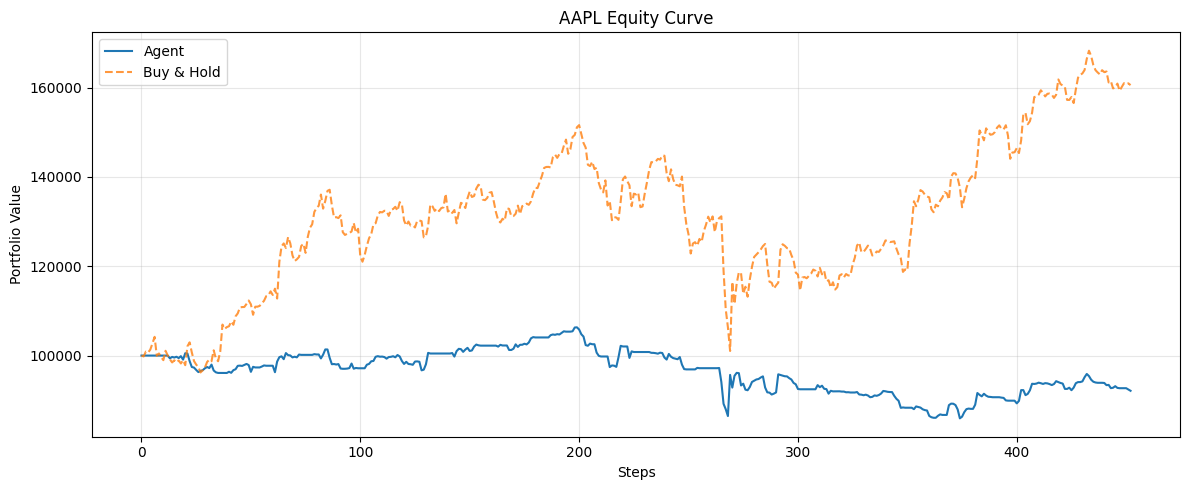

AMD
------------------------------------------------------------
Total Return: -20.7443%
Win Rate:     30.97%
Final Value:  79255.679688

Action Distribution:
  ALLOC_0    Count:  152 |  33.63%
  ALLOC_35   Count:  176 |  38.94%
  ALLOC_70   Count:  124 |  27.43%


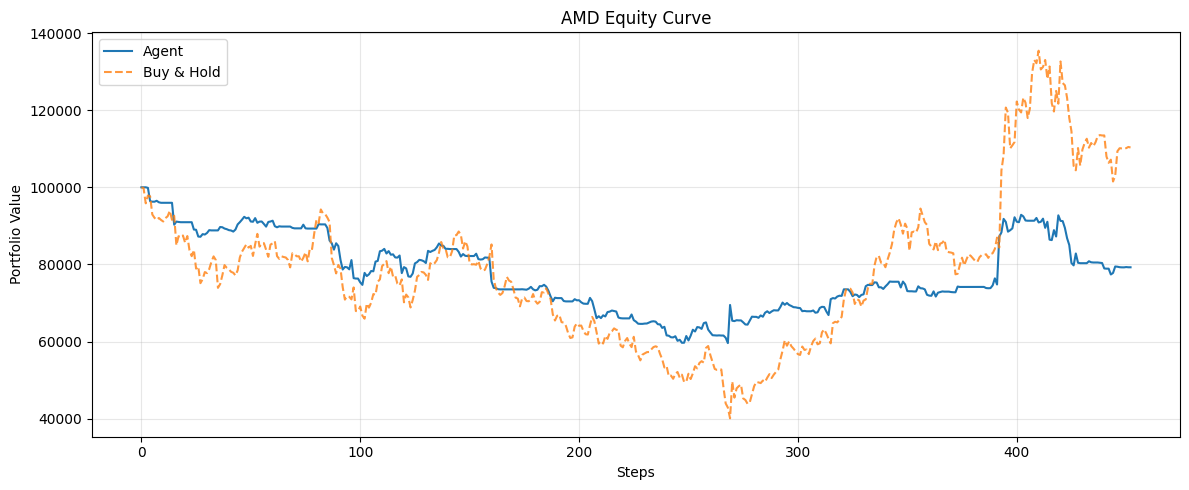

AMZN
------------------------------------------------------------
Total Return: -3.0433%
Win Rate:     28.10%
Final Value:  96956.734375

Action Distribution:
  ALLOC_0    Count:  189 |  41.81%
  ALLOC_35   Count:  134 |  29.65%
  ALLOC_70   Count:  129 |  28.54%


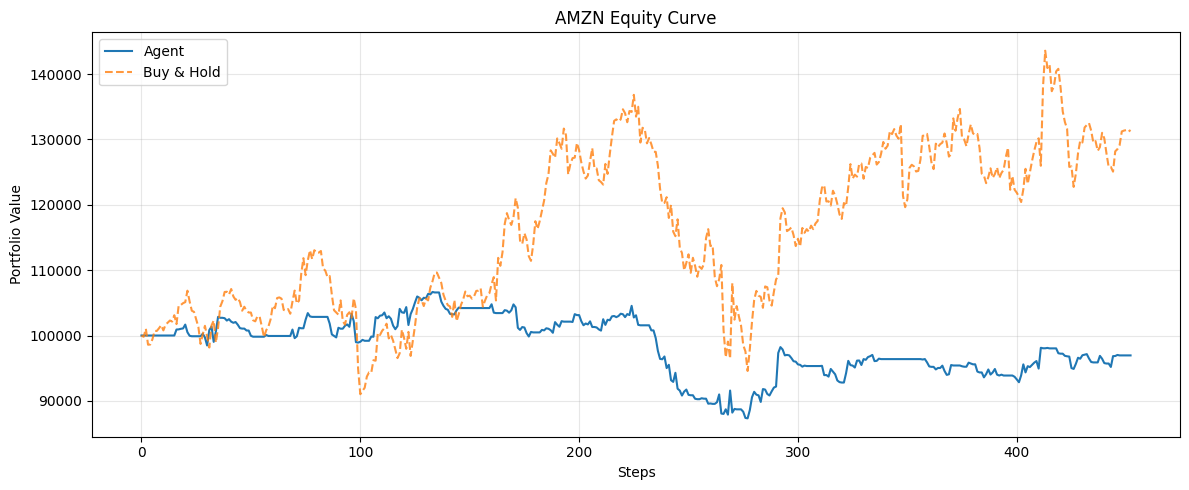

CSCO
------------------------------------------------------------
Total Return: 3.9116%
Win Rate:     30.31%
Final Value:  103911.585938

Action Distribution:
  ALLOC_0    Count:  166 |  36.73%
  ALLOC_35   Count:  117 |  25.88%
  ALLOC_70   Count:  169 |  37.39%


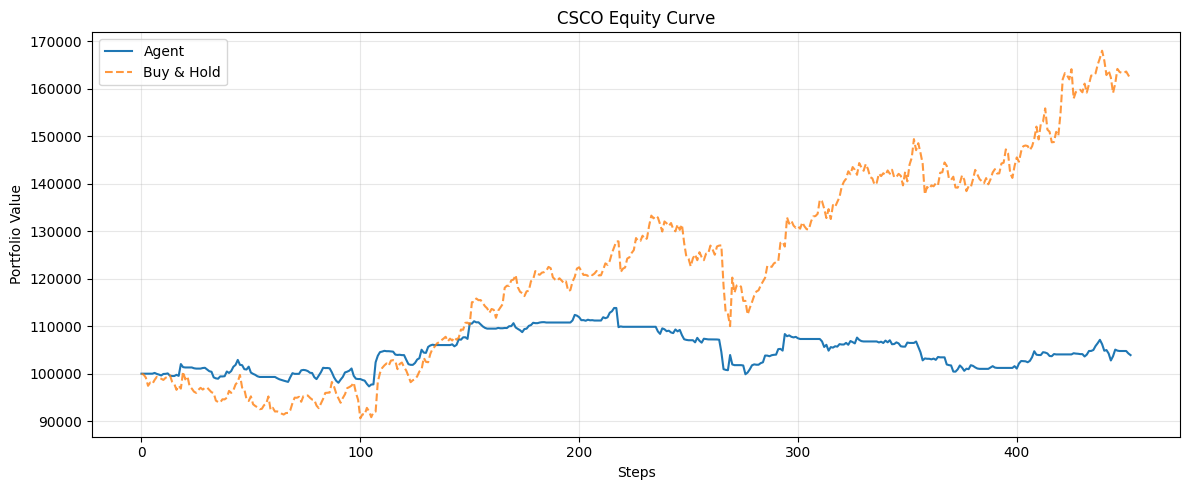

GOOGL
------------------------------------------------------------
Total Return: 15.8786%
Win Rate:     32.30%
Final Value:  115878.585938

Action Distribution:
  ALLOC_0    Count:  175 |  38.72%
  ALLOC_35   Count:  140 |  30.97%
  ALLOC_70   Count:  137 |  30.31%


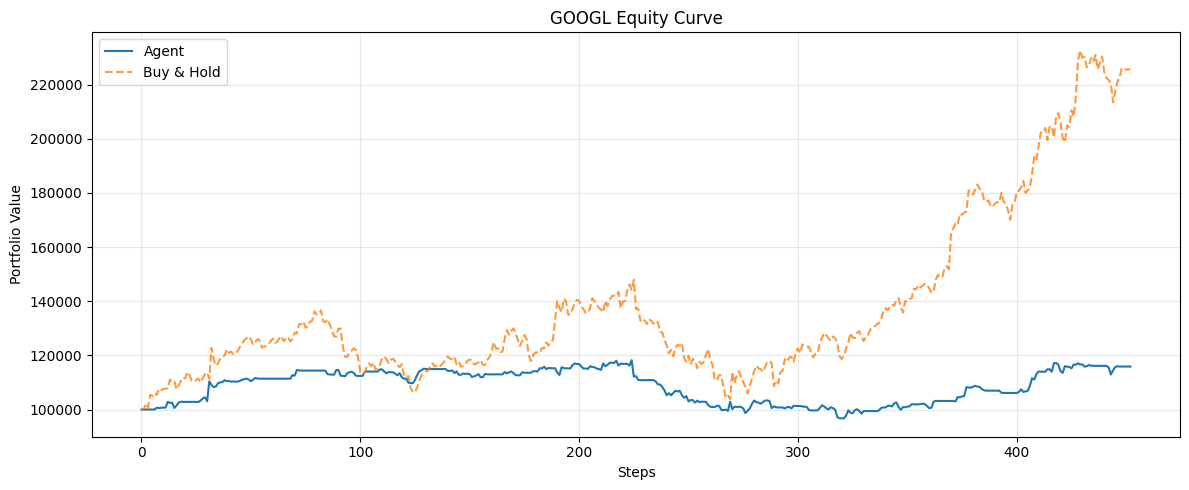

INTC
------------------------------------------------------------
Total Return: -1.5416%
Win Rate:     28.98%
Final Value:  98458.390625

Action Distribution:
  ALLOC_0    Count:  167 |  36.95%
  ALLOC_35   Count:  182 |  40.27%
  ALLOC_70   Count:  103 |  22.79%


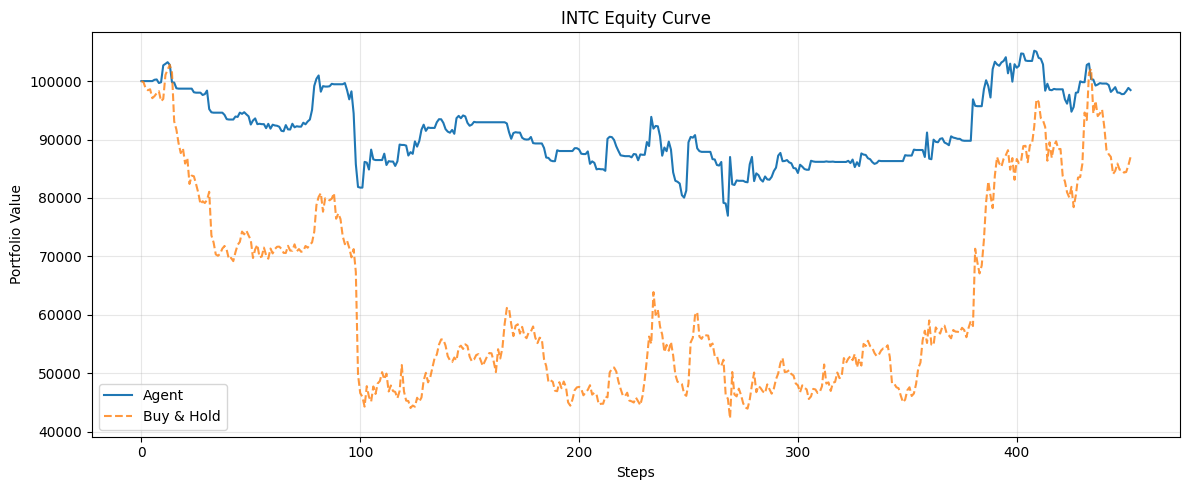

META
------------------------------------------------------------
Total Return: 2.1290%
Win Rate:     29.20%
Final Value:  102129.046875

Action Distribution:
  ALLOC_0    Count:  187 |  41.37%
  ALLOC_35   Count:  142 |  31.42%
  ALLOC_70   Count:  123 |  27.21%


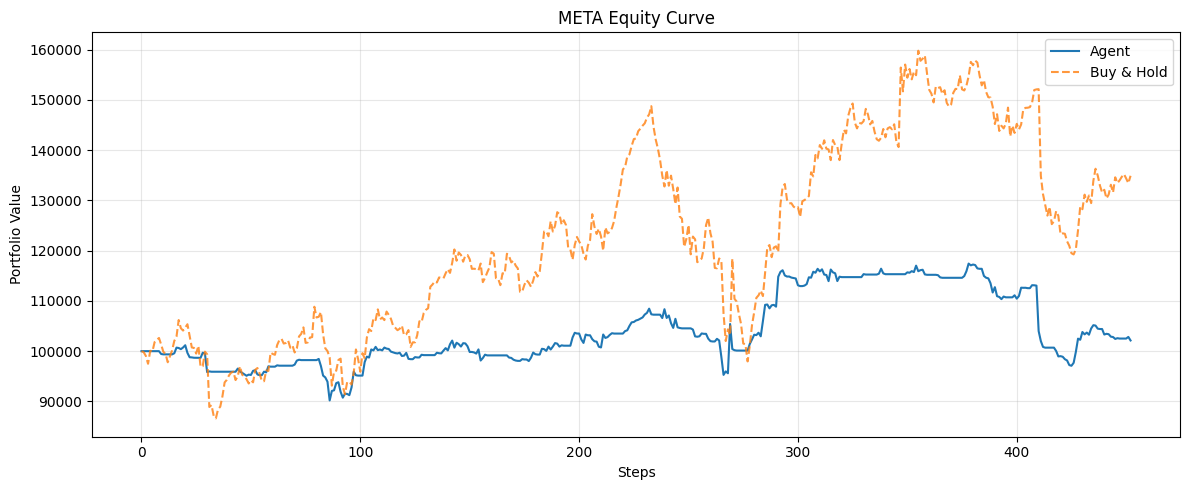

MSFT
------------------------------------------------------------
Total Return: -5.5974%
Win Rate:     26.99%
Final Value:  94402.570312

Action Distribution:
  ALLOC_0    Count:  203 |  44.91%
  ALLOC_35   Count:  129 |  28.54%
  ALLOC_70   Count:  120 |  26.55%


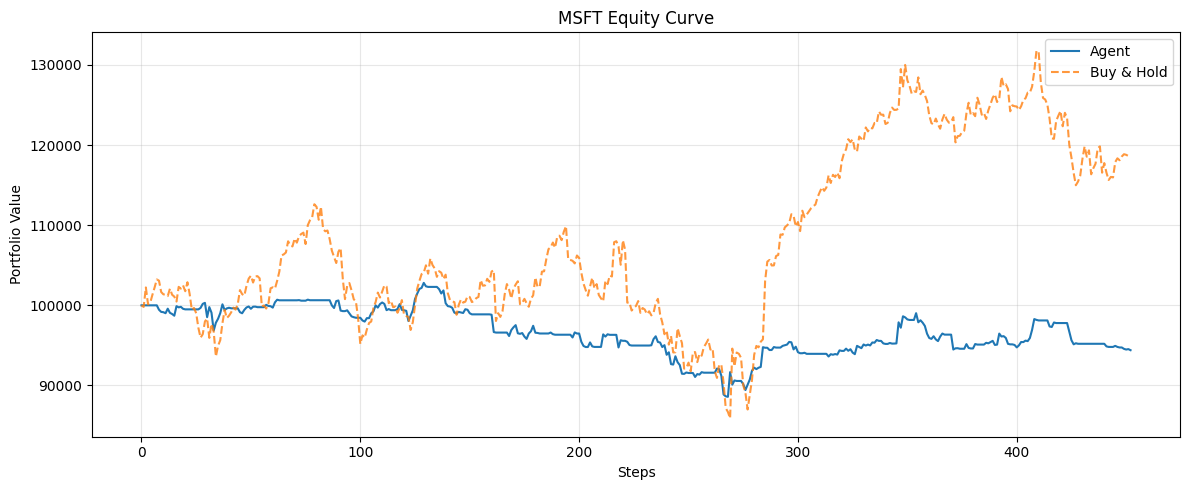

NVDA
------------------------------------------------------------
Total Return: 23.3583%
Win Rate:     36.95%
Final Value:  123358.335938

Action Distribution:
  ALLOC_0    Count:  127 |  28.10%
  ALLOC_35   Count:  182 |  40.27%
  ALLOC_70   Count:  143 |  31.64%


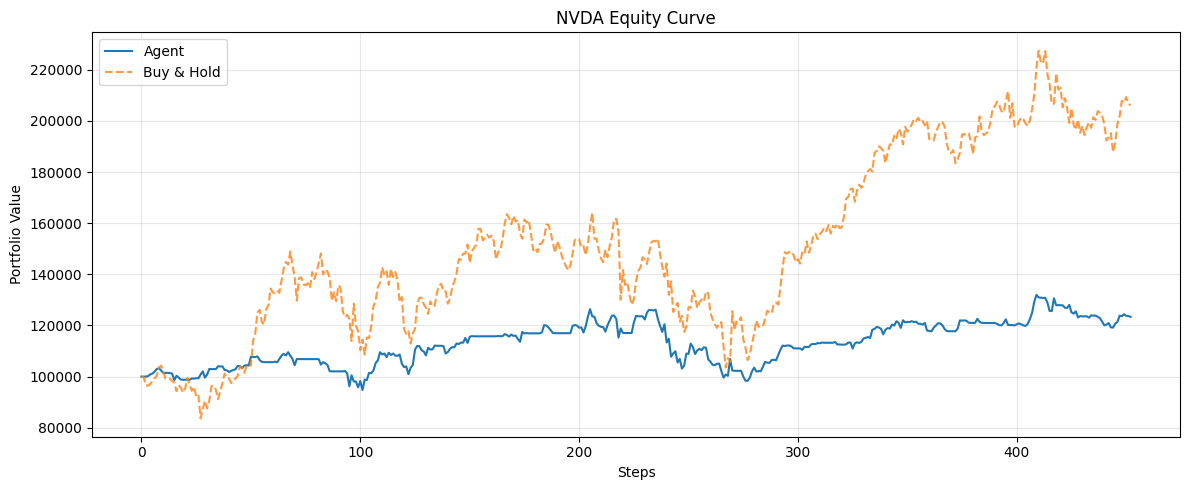

TSLA
------------------------------------------------------------
Total Return: 8.6272%
Win Rate:     35.18%
Final Value:  108627.156250

Action Distribution:
  ALLOC_0    Count:  133 |  29.42%
  ALLOC_35   Count:  173 |  38.27%
  ALLOC_70   Count:  146 |  32.30%


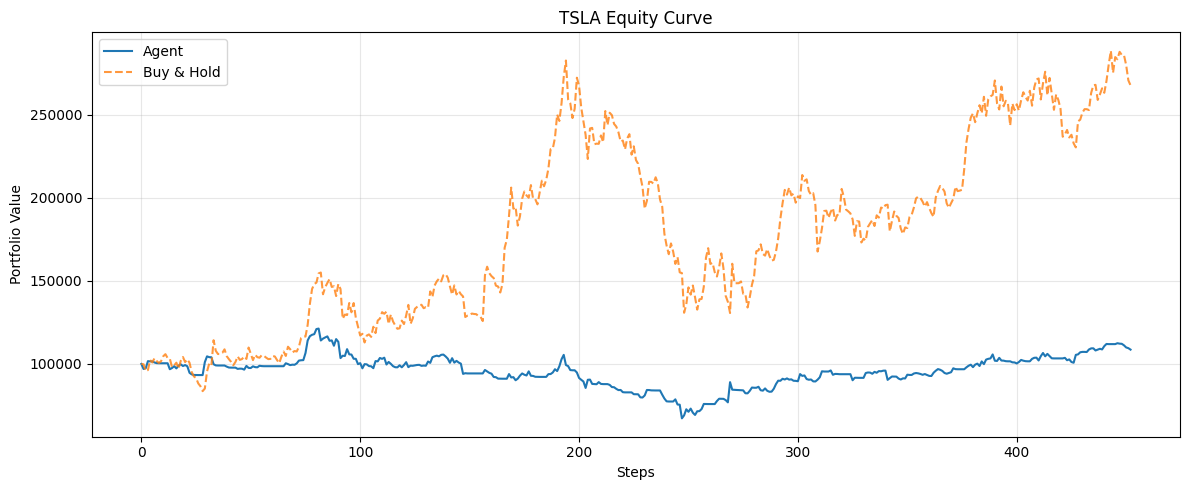

In [8]:
results_best_model = backtest(
    best_model,
    test_states,
    test_prices,
    tickers=tickers,
    steps_per_day=1
)

avg_return = sum(m['Total Return (%)'] for m in results_best_model.values()) / len(results_best_model)
print(f"Average Return: {avg_return:.4f}%")

for i, (ticker, metrics) in enumerate(results_best_model.items()):

    print("="*60)
    print(ticker)
    print("-"*60)

    print(f"Total Return: {metrics['Total Return (%)']:.4f}%")
    print(f"Win Rate:     {metrics['Win Rate (%)']:.2f}%")
    print(f"Final Value:  {metrics['Final Value']:.6f}")

    print("\nAction Distribution:")
    for action_name, stats in metrics["Action Distribution"].items():
        print(
            f"  {action_name:<10} "
            f"Count: {stats['count']:>4} | "
            f"{stats['percentage']:>6.2f}%"
        )

    print("="*60)

    #Buy & Hold Benchmark
    bh_equity = compute_buyhold_equity(test_prices[i])

    # Đảm bảo 2 curve cùng length
    min_len = min(len(metrics["Equity Curve"]), len(bh_equity))

    plot_equity(
        metrics["Equity Curve"][:min_len],
        title=f"{ticker} Equity Curve",
        benchmark=bh_equity[:min_len]
    )